# Mount Beauty, Victoria — Street Node Network

This notebook installs `osmnx` and uses it to download and plot the street network (nodes and edges) for Mount Beauty, Victoria, Australia, pulled live from OpenStreetMap.

## 1. Install dependencies
It installs `osmnx` and its main dependencies (`networkx`, `matplotlib`, `geopandas`, etc.).

In [1]:
import sys
!{sys.executable} -m pip install --quiet osmnx networkx matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import sys
print(sys.executable)

/opt/conda/envs/anaconda-2025.12-py312/bin/python


In [6]:
%pip install --quiet osmnx networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Import libraries

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt

ox.settings.log_console = True
ox.settings.use_cache = True

print('osmnx version:', ox.__version__)

Matplotlib is building the font cache; this may take a moment.


osmnx version: 2.1.1


## 3. Download the street network
We query OpenStreetMap for the place name "Mount Beauty, Victoria, Australia" and build a `networkx` graph of the drivable street network. Change `network_type` to `'all'`, `'walk'`, or `'bike'` if you want a different network.

In [2]:
place_name = "Mount Beauty, Victoria, Australia"

# network_type options: 'drive', 'walk', 'bike', 'all', 'all_private'
G = ox.graph_from_place(place_name, network_type="drive")

print(f"Graph for {place_name}:")
print(f"  Nodes: {len(G.nodes)}")
print(f"  Edges: {len(G.edges)}")

Graph for Mount Beauty, Victoria, Australia:
  Nodes: 83
  Edges: 214


## 4. Plot the street node network
This plots the graph with nodes (intersections/street endpoints) visible on top of the edges (street segments).

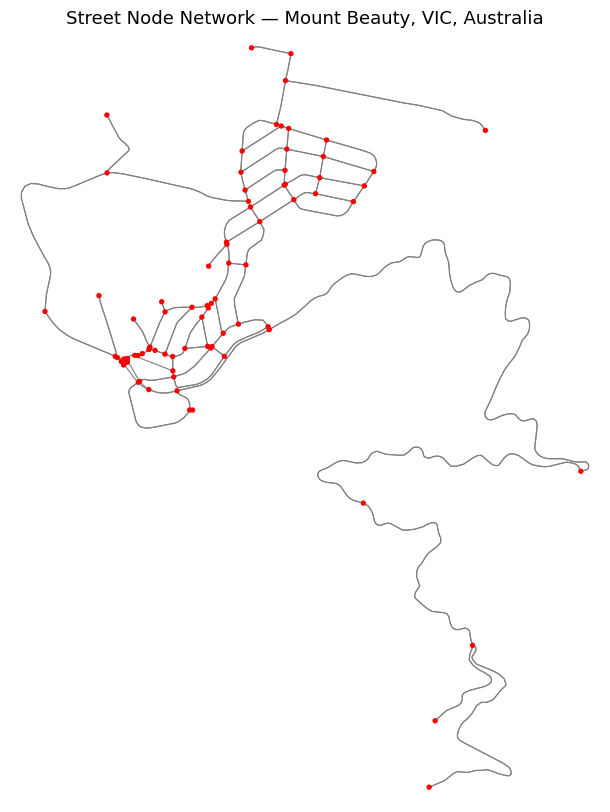

In [3]:
fig, ax = ox.plot_graph(
    G,
    node_size=15,
    node_color="red",
    node_zorder=3,
    edge_color="gray",
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False,
)
ax.set_title("Street Node Network — Mount Beauty, VIC, Australia", fontsize=13)
plt.show()

## 5. (Optional) Save the graph and figure to disk

In [4]:
# Save the figure as a PNG
fig.savefig("mount_beauty_street_network.png", dpi=300, bbox_inches="tight")

# Save the graph itself for later reuse (as GraphML)
ox.save_graphml(G, filepath="mount_beauty_street_network.graphml")

print("Saved: mount_beauty_street_network.png and mount_beauty_street_network.graphml")

Saved: mount_beauty_street_network.png and mount_beauty_street_network.graphml


## 6. (Optional) Basic network stats

In [ ]:
stats = ox.basic_stats(G)
for k, v in stats.items():
    print(f"{k}: {v}")